In [2]:
#This notebook is created by Fayaz i just only apply here linear regression nothing else i guess this notebook will be helpful 
# for those who are beginners on kaggle  

import numpy as np 
import pandas as pd 


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub


/kaggle/input/datasets/oossiiris/hackerearth-machine-learning-exhibit-art/dataset/sample_submission.csv
/kaggle/input/datasets/oossiiris/hackerearth-machine-learning-exhibit-art/dataset/train.csv
/kaggle/input/datasets/oossiiris/hackerearth-machine-learning-exhibit-art/dataset/test.csv


In [3]:
import warnings 
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)

In [4]:
df =pd.read_csv("/kaggle/input/datasets/oossiiris/hackerearth-machine-learning-exhibit-art/dataset/train.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6500 entries, 0 to 6499
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Customer Id            6500 non-null   object 
 1   Artist Name            6500 non-null   object 
 2   Artist Reputation      5750 non-null   float64
 3   Height                 6125 non-null   float64
 4   Width                  5916 non-null   float64
 5   Weight                 5913 non-null   float64
 6   Material               5736 non-null   object 
 7   Price Of Sculpture     6500 non-null   float64
 8   Base Shipping Price    6500 non-null   float64
 9   International          6500 non-null   object 
 10  Express Shipment       6500 non-null   object 
 11  Installation Included  6500 non-null   object 
 12  Transport              5108 non-null   object 
 13  Fragile                6500 non-null   object 
 14  Customer Information   6500 non-null   object 
 15  Remo

In [6]:
df.isnull().sum()

Customer Id                 0
Artist Name                 0
Artist Reputation         750
Height                    375
Width                     584
Weight                    587
Material                  764
Price Of Sculpture          0
Base Shipping Price         0
International               0
Express Shipment            0
Installation Included       0
Transport                1392
Fragile                     0
Customer Information        0
Remote Location           771
Scheduled Date              0
Delivery Date               0
Customer Location           0
Cost                        0
dtype: int64

In [7]:
df.head()

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,Express Shipment,Installation Included,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,Yes,No,Airways,No,Working Class,No,06/07/15,06/03/15,"New Michelle, OH 50777",-283.29
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,No,No,Roadways,No,Working Class,No,03/06/17,03/05/17,"New Michaelport, WY 12072",-159.96
2,fffe3600370035003100,Laura Miller,0.07,8.0,5.0,237.0,Clay,4.96,21.18,No,No,No,Roadways,Yes,Working Class,Yes,03/09/15,03/08/15,"Bowmanshire, WA 19241",-154.29
3,fffe350031003300,Robert Chaires,0.12,9.0,NaN,NaN,Aluminium,5.81,16.31,No,No,No,NaN,No,Wealthy,Yes,05/24/15,05/20/15,"East Robyn, KY 86375",-161.16
4,fffe3900320038003400,Rosalyn Krol,0.15,17.0,6.0,324.0,Aluminium,3.18,11.94,Yes,Yes,Yes,Airways,No,Working Class,No,12/18/16,12/14/16,"Aprilside, PA 52793",-159.23


In [8]:
target= 'Cost'

Most of the feature seems to be of object data type , So we first need to separate them for better analysis. We have two types of feature that is numeric feature and the other is categorical feature.

In [9]:
numerical_features = [i for i in df.columns if df[i].dtype != 'O']
categorical_features = [i for i in df.columns if df[i].dtype =='O']

print("We have {} numerical_features : {}".format(len(numerical_features), numerical_features))
print("We have {} categorical_features : {}".format(len(categorical_features ), categorical_features ))

We have 7 numerical_features : ['Artist Reputation', 'Height', 'Width', 'Weight', 'Price Of Sculpture', 'Base Shipping Price', 'Cost']
We have 13 categorical_features : ['Customer Id', 'Artist Name', 'Material', 'International', 'Express Shipment', 'Installation Included', 'Transport', 'Fragile', 'Customer Information', 'Remote Location', 'Scheduled Date', 'Delivery Date', 'Customer Location']


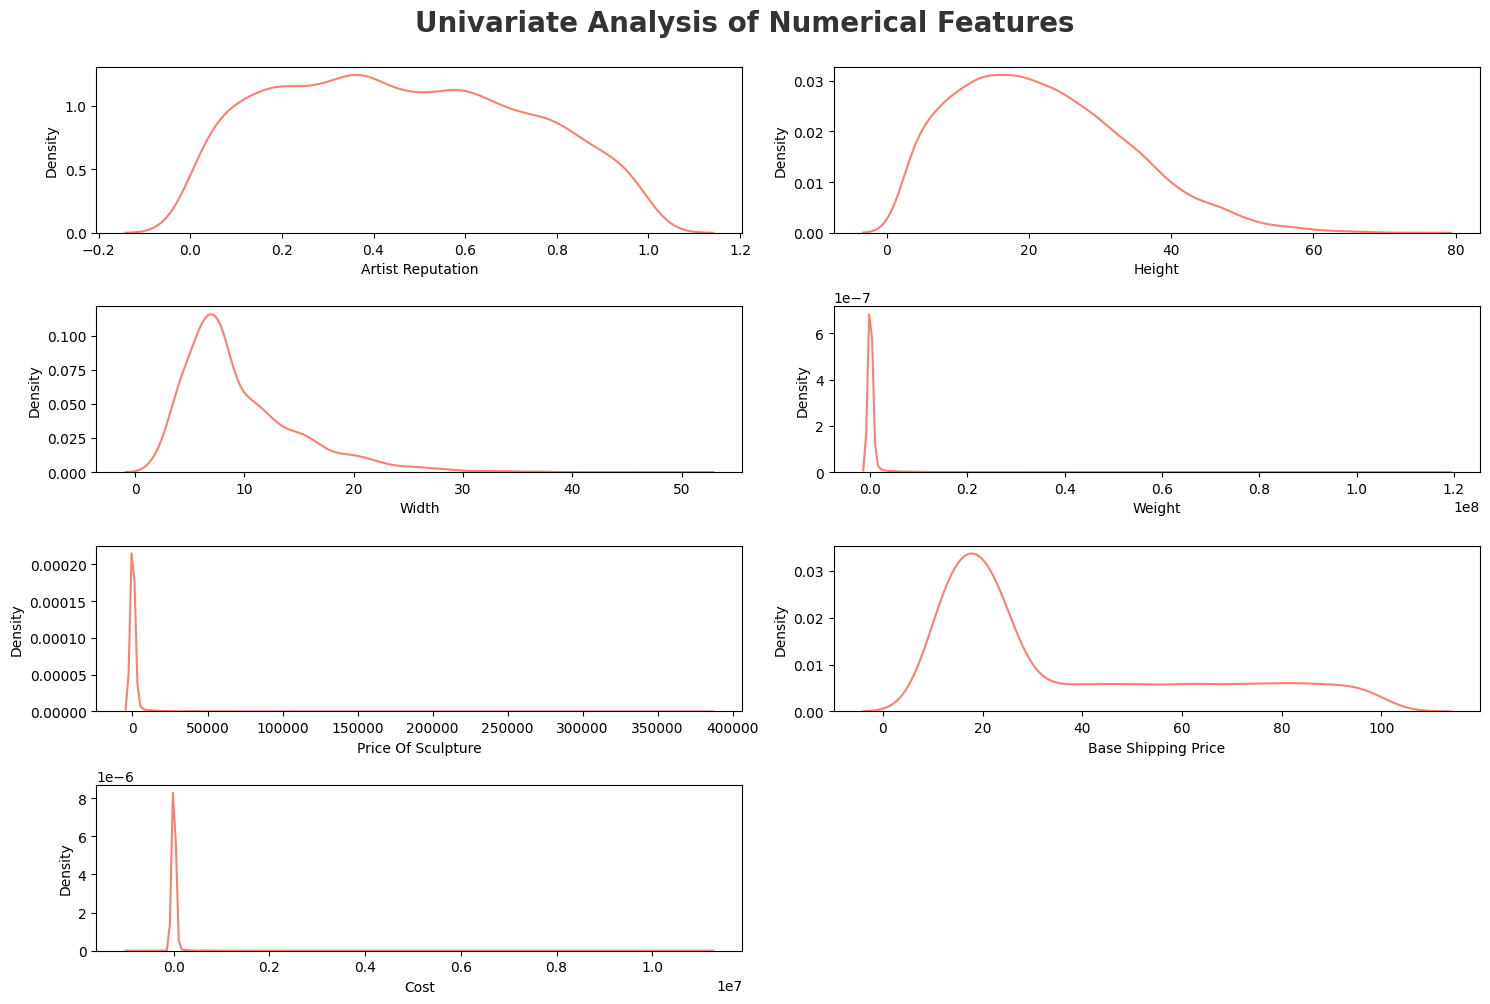

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numerical_features)):
    plt.subplot(4, 2, i+1)
    sns.kdeplot(x=df[numerical_features[i]], color='salmon')
    plt.xlabel(numerical_features[i])
    plt.tight_layout()

Weight and Price of Sculpture has outliers

In [11]:
#I consider a column categorical if it has fewer than 10 distinct values.
categorical_columns=[]
for i in categorical_features:
    print(f' {i} : {len(df[i].unique())}')
    if(len(df[i].unique()))<10:
        categorical_columns.append(i)

 Customer Id : 6500
 Artist Name : 6449
 Material : 8
 International : 2
 Express Shipment : 2
 Installation Included : 2
 Transport : 4
 Fragile : 2
 Customer Information : 2
 Remote Location : 3
 Scheduled Date : 1660
 Delivery Date : 1664
 Customer Location : 6500


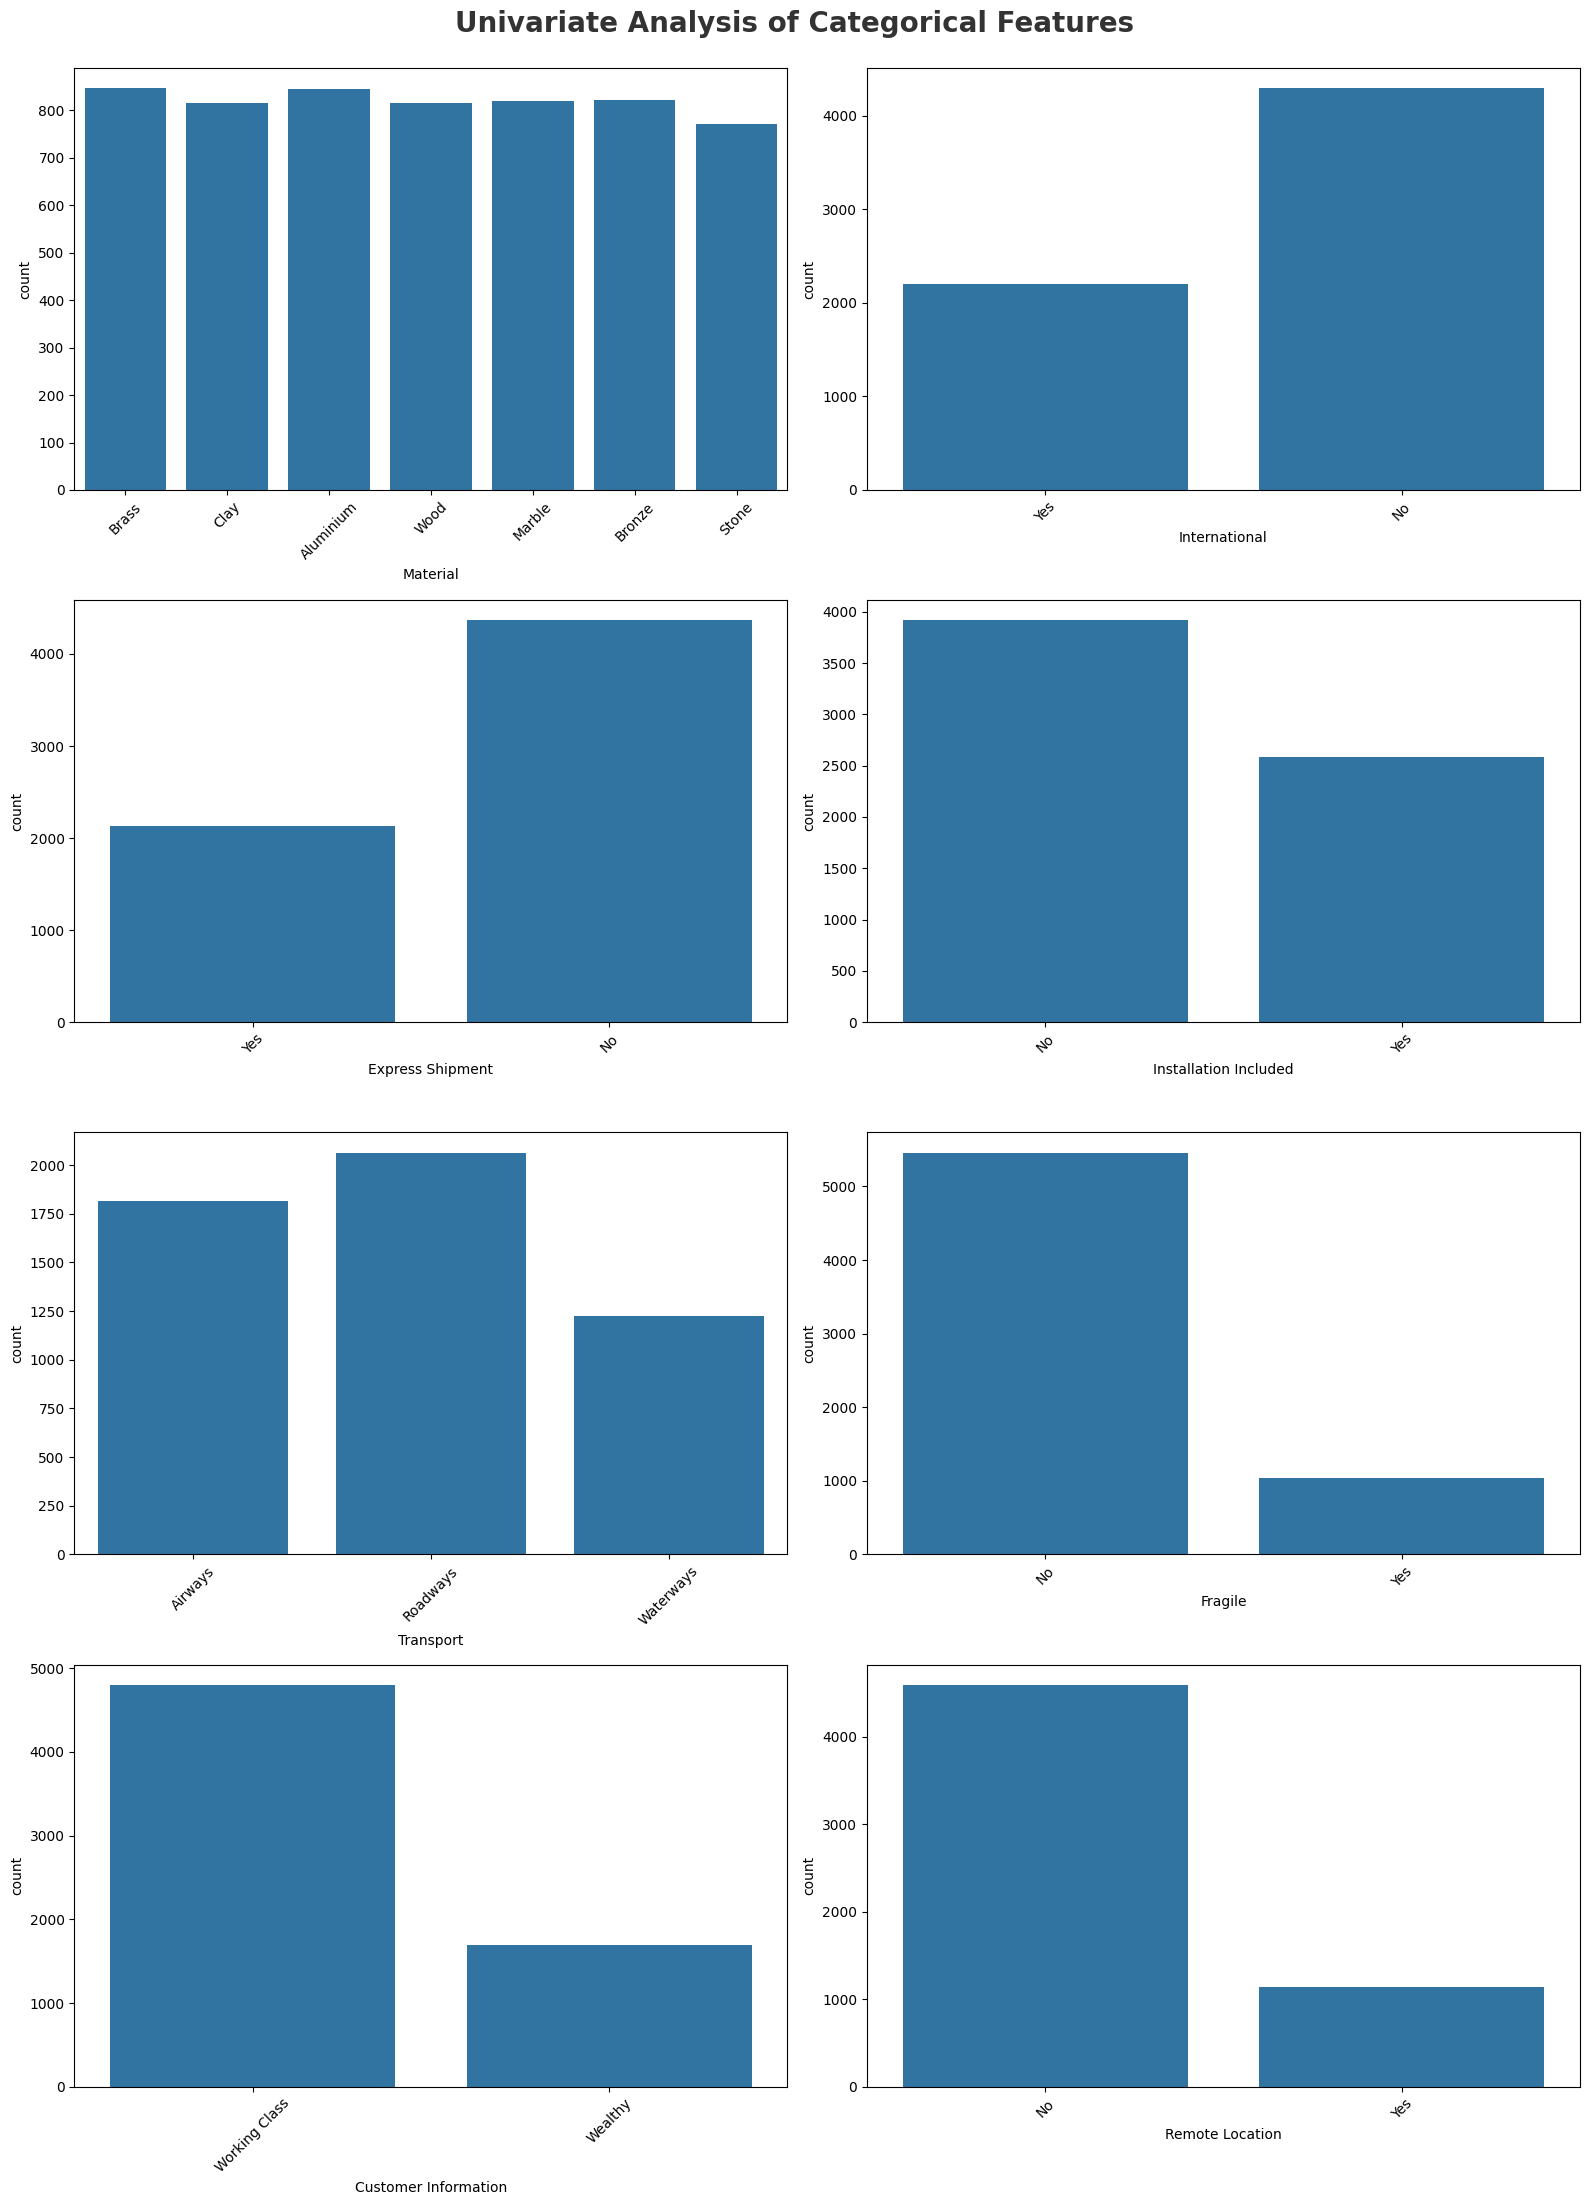

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 22))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
for i in range(0, len(categorical_columns)):
    plt.subplot(4, 2, i+1)
    sns.countplot(x=df[categorical_columns[i]])
    plt.xlabel(categorical_columns[i])
    plt.xticks(rotation=45)
    plt.tight_layout()

There are 6 bi-variate categorical columns

In [13]:
df.isnull().sum()

Customer Id                 0
Artist Name                 0
Artist Reputation         750
Height                    375
Width                     584
Weight                    587
Material                  764
Price Of Sculpture          0
Base Shipping Price         0
International               0
Express Shipment            0
Installation Included       0
Transport                1392
Fragile                     0
Customer Information        0
Remote Location           771
Scheduled Date              0
Delivery Date               0
Customer Location           0
Cost                        0
dtype: int64

7 columns has null values

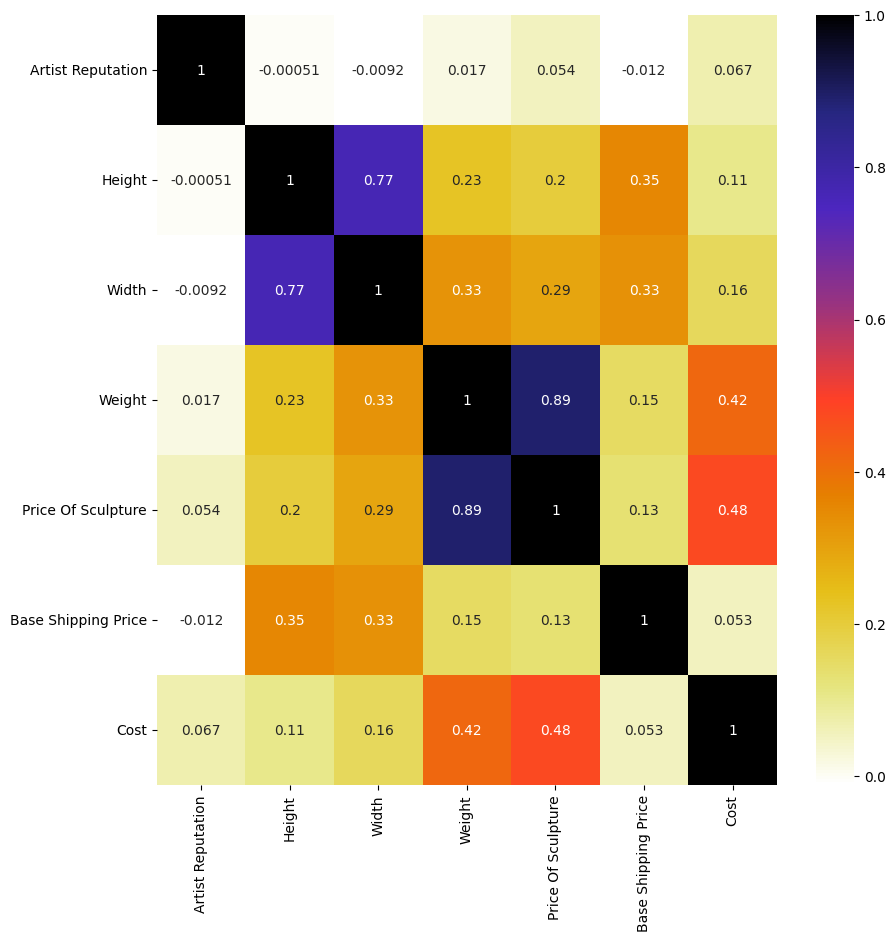

In [14]:
df[(list(df.columns)[1:])].corr(numeric_only=True)
plt.figure(figsize = (10,10))
sns.heatmap(df.corr(numeric_only=True), cmap="CMRmap_r", annot=True)
plt.show()

High Correlation between height and width , Price of Sculpture and Weight 

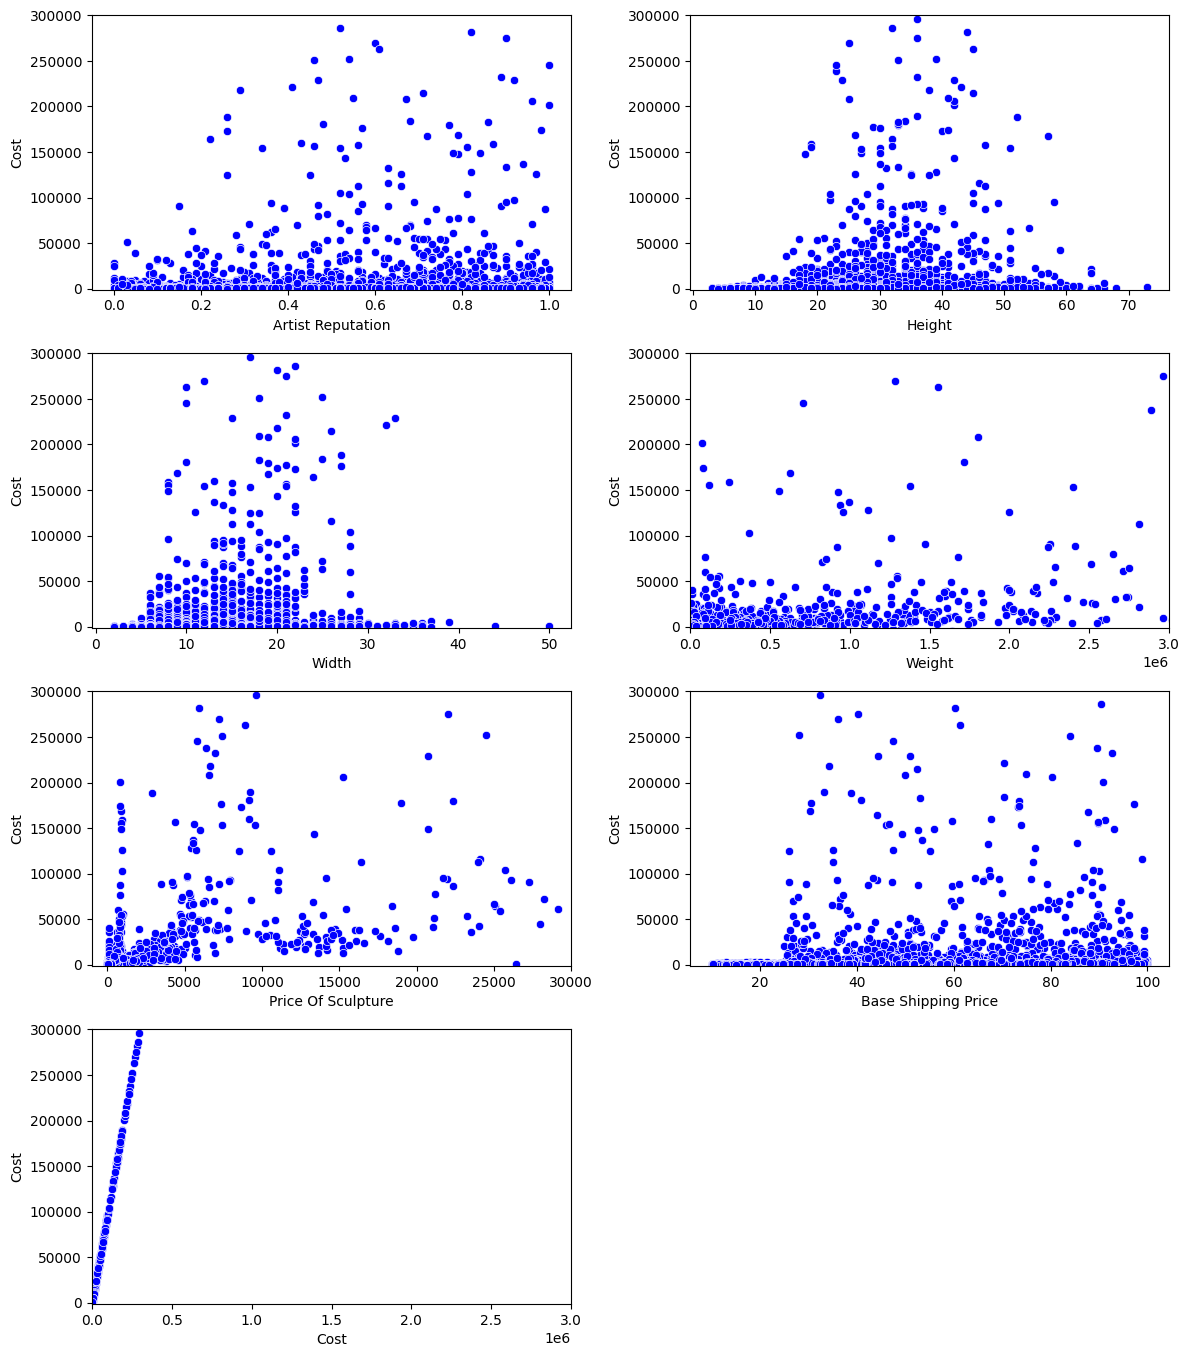

In [15]:
fig = plt.figure(figsize=(12, 20))

for i in range(0, len(numerical_features)):
    ax = plt.subplot(6, 2, i+1)
    sns.scatterplot(data= df ,y=target, x=numerical_features[i], color='b')
    if df[numerical_features[i]].max() > 30000:
        plt.xlim(-1000,30000)
    if df[numerical_features[i]].max() > 3000000:
        plt.xlim(-1000,3000000)
    plt.ylim(-1000, 300000)
    plt.tight_layout()

We can observe that there seems to be very low linear relationship between the independent and dependent features

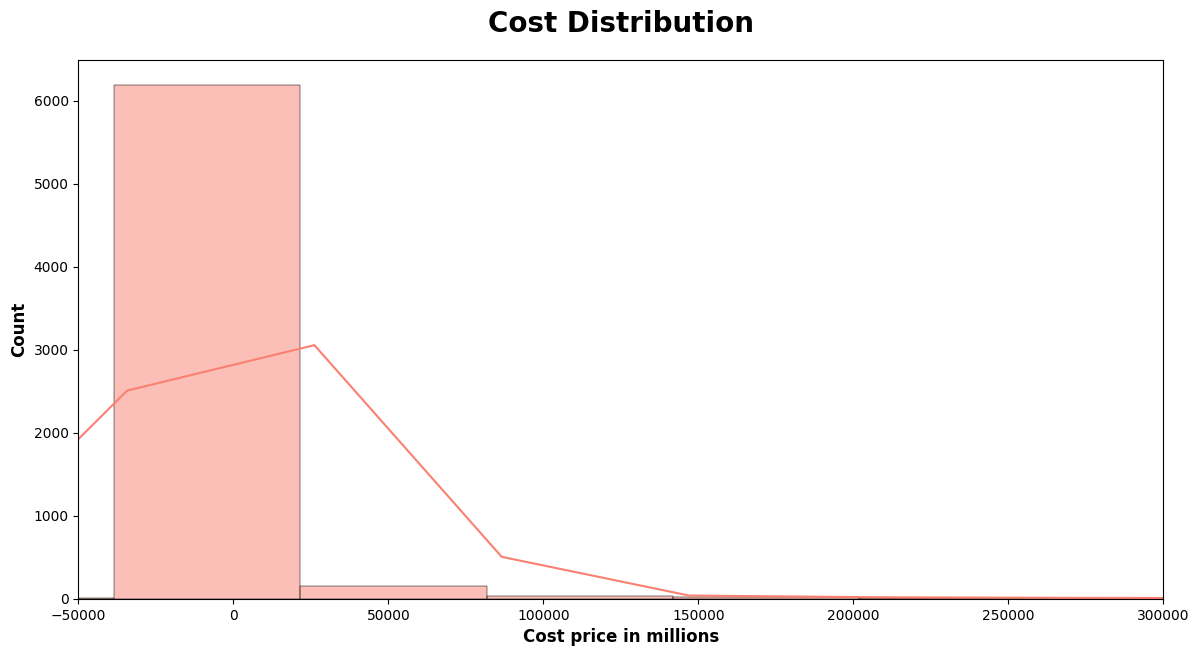

In [16]:
plt.subplots(figsize=(14,7))
sns.histplot(df[target], bins=200, kde=True, color = 'salmon')
plt.title("Cost Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Cost price in millions", weight="bold", fontsize=12)
plt.xlim(-50000,300000)
plt.show()

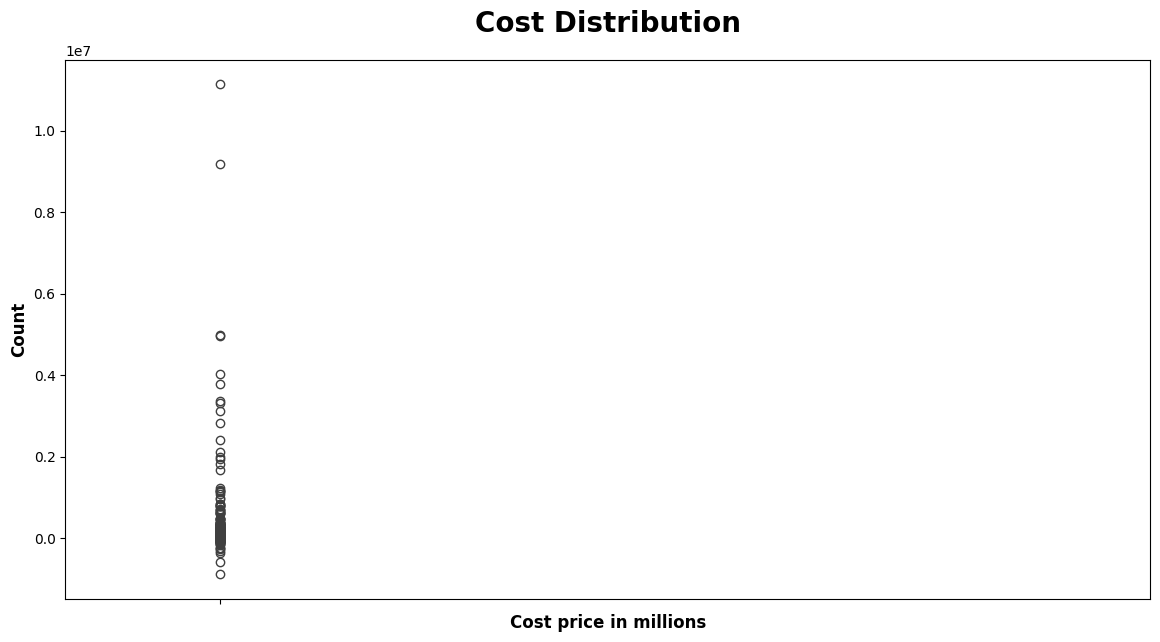

In [17]:
plt.subplots(figsize=(14,7))
sns.boxplot(df[target])
plt.title("Cost Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Cost price in millions", weight="bold", fontsize=12)
plt.xlim(-50000,300000);

**There are outliers in the target feature and we need to transform**

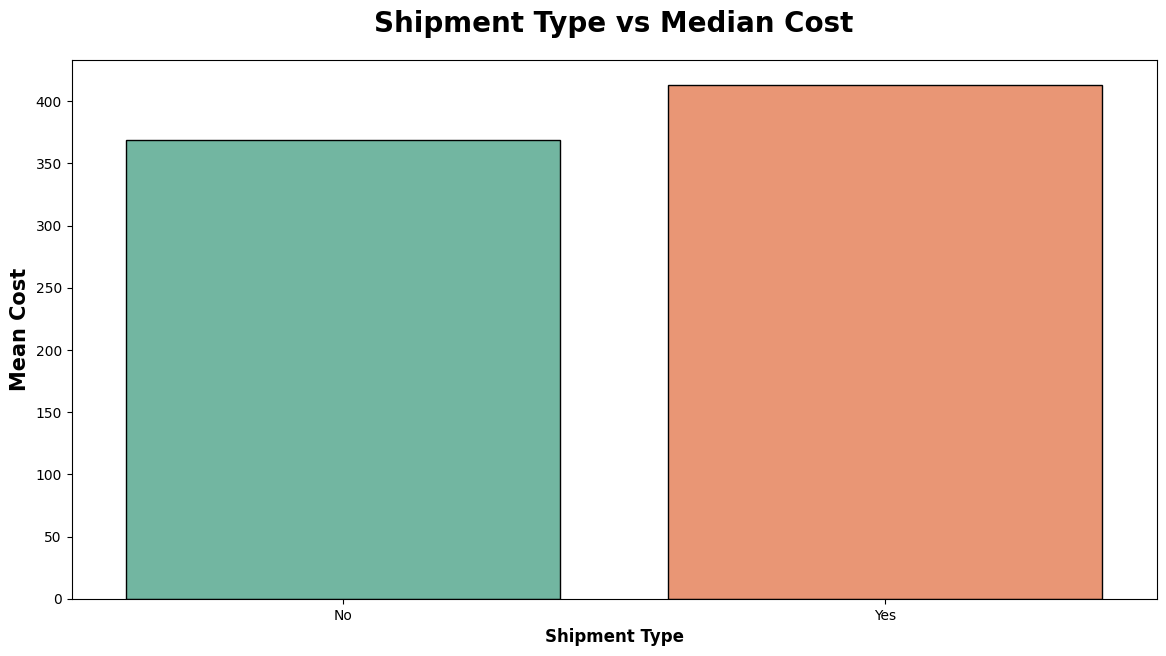

In [18]:
international = df.groupby('International')[target].median()
international.to_frame()

plt.subplots(figsize=(14,7))
sns.barplot(x=international.index, y=international.values, ec = "black", palette="Set2")
plt.title("Shipment Type vs Median Cost", weight="bold",fontsize=20, pad=20)
plt.ylabel("Mean Cost", weight="bold", fontsize=15)
plt.xlabel("Shipment Type", weight="bold", fontsize=12)
plt.show()

# International type is higher cost

In [19]:
df['International'].value_counts()

International
No     4294
Yes    2206
Name: count, dtype: int64

# Median is more robust to outliers, so analysts often compare medians when studying shipment costs.

In [20]:
international_shipment_median = df[df['International'] == 'Yes']['Cost'].median()
domestic_shipment_median = df[df['International'] == 'No']['Cost'].median()

print(f"The difference between the median shipment price of International and domestic is {international_shipment_median-domestic_shipment_median}")

The difference between the median shipment price of International and domestic is 43.91500000000008


In [21]:
df.head()

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,Express Shipment,Installation Included,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,Yes,No,Airways,No,Working Class,No,06/07/15,06/03/15,"New Michelle, OH 50777",-283.29
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,No,No,Roadways,No,Working Class,No,03/06/17,03/05/17,"New Michaelport, WY 12072",-159.96
2,fffe3600370035003100,Laura Miller,0.07,8.0,5.0,237.0,Clay,4.96,21.18,No,No,No,Roadways,Yes,Working Class,Yes,03/09/15,03/08/15,"Bowmanshire, WA 19241",-154.29
3,fffe350031003300,Robert Chaires,0.12,9.0,NaN,NaN,Aluminium,5.81,16.31,No,No,No,NaN,No,Wealthy,Yes,05/24/15,05/20/15,"East Robyn, KY 86375",-161.16
4,fffe3900320038003400,Rosalyn Krol,0.15,17.0,6.0,324.0,Aluminium,3.18,11.94,Yes,Yes,Yes,Airways,No,Working Class,No,12/18/16,12/14/16,"Aprilside, PA 52793",-159.23


## 1. Express Shipment Represents whether the shipping was in the express (fast) mode
## 2. How much higher (or lower) is the typical shipment cost for international shipments compared to domestic shipments?

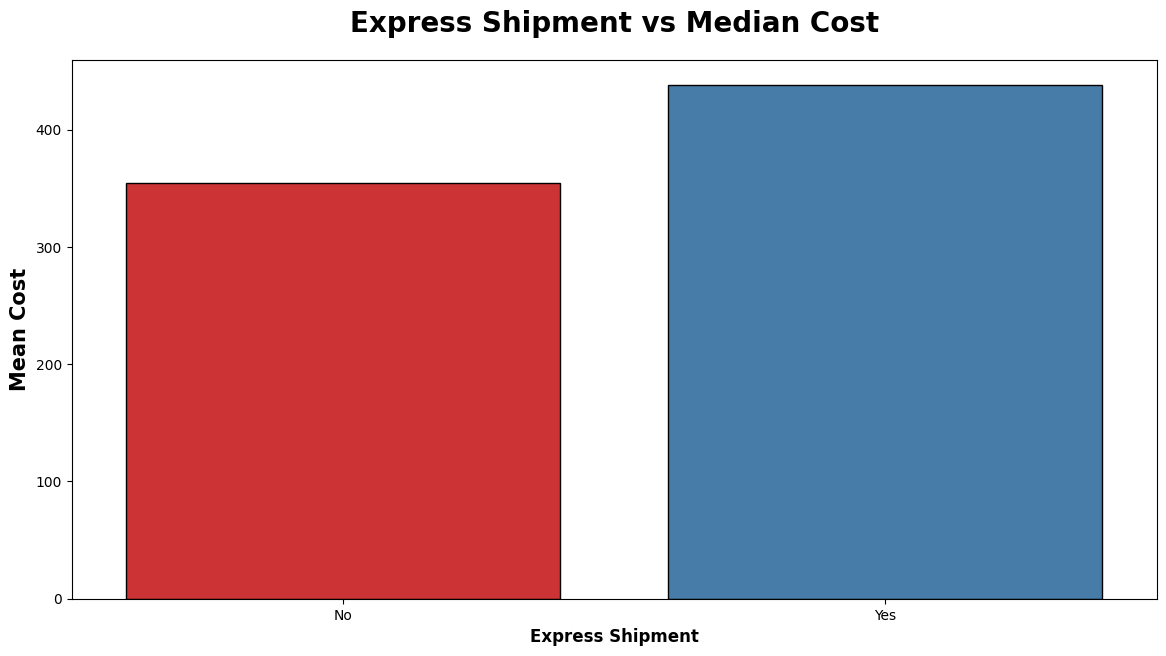

In [22]:
express_ship = df.groupby('Express Shipment')[target].median()
express_ship.to_frame()

plt.subplots(figsize=(14,7))
sns.barplot(x=express_ship.index, y=express_ship.values, ec = "black", palette="Set1")
plt.title("Express Shipment vs Median Cost", weight="bold",fontsize=20, pad=20)
plt.ylabel("Mean Cost", weight="bold", fontsize=15)
plt.xlabel("Express Shipment", weight="bold", fontsize=12)
plt.show()

## Visualizing the date columns


In [23]:
import pandas as pd
df['Scheduled Date'] = pd.to_datetime(df['Scheduled Date'])
df['Delivery Date'] = pd.to_datetime(df['Delivery Date'])
df['year'] = pd.DatetimeIndex(df['Scheduled Date']).year
df['month'] = pd.DatetimeIndex(df['Scheduled Date']).month

## Step 1: Group by year and month
| year | month | Cost |
| ---- | ----- | ---- |
| 2024 | 1     | 100  |
| 2024 | 1     | 120  |
| 2024 | 2     | 150  |
| 2025 | 1     | 200  |
| 2025 | 2     | 220  |

x = df.groupby(["year", "month"])["Cost"].mean()


Output:

    year          month

    2024  1        110.0

          2        150.0

      
      
    2025  1        200.0

          2        220.0


## Step -02: Unstack
Notice this is a MultiIndex Series
df_wide = x.unstack() , unstack() converts one level of the index into columns.
| year | 1   | 2   |
| ---- | --- | --- |
| 2024 | 110 | 150 |
| 2025 | 200 | 220 |

Here:
Rows = years
Columns = months
## Step 3: Transpose
df_wide = x.unstack().T , .T means transpose. Rows become columns and columns become rows.
| month | 2024 | 2025 |
| ----- | ---- | ---- |
| 1     | 110  | 200  |
| 2     | 150  | 220  |
This format is perfect for: Heatmaps , Comparing years month-by-month


In [24]:
x = df.groupby(["year", "month"])["Cost"].mean()
df_wide = x.unstack().T
df_wide.head()

year,2015,2016,2017,2018,2019
month,,,,,
1,1243.620800,12930.272703,13388.419779,47457.768519,2430.550495
2,34249.351818,10034.132545,3427.163673,6612.238687,3840.484630
3,23775.741185,10757.195810,41359.835804,20026.385455,2265.834019
4,94668.648276,4288.732696,26634.491452,4138.730309,8374.422975
5,15884.313833,4103.283514,8857.153077,17461.434118,14129.902741


In [25]:
df_wide[2016]

month
1     12930.272703
2     10034.132545
3     10757.195810
4      4288.732696
5      4103.283514
6     12773.907113
7      5375.828978
8     10069.254050
9     20046.773929
10    20613.512273
11     7505.164333
12     2370.201793
Name: 2016, dtype: float64

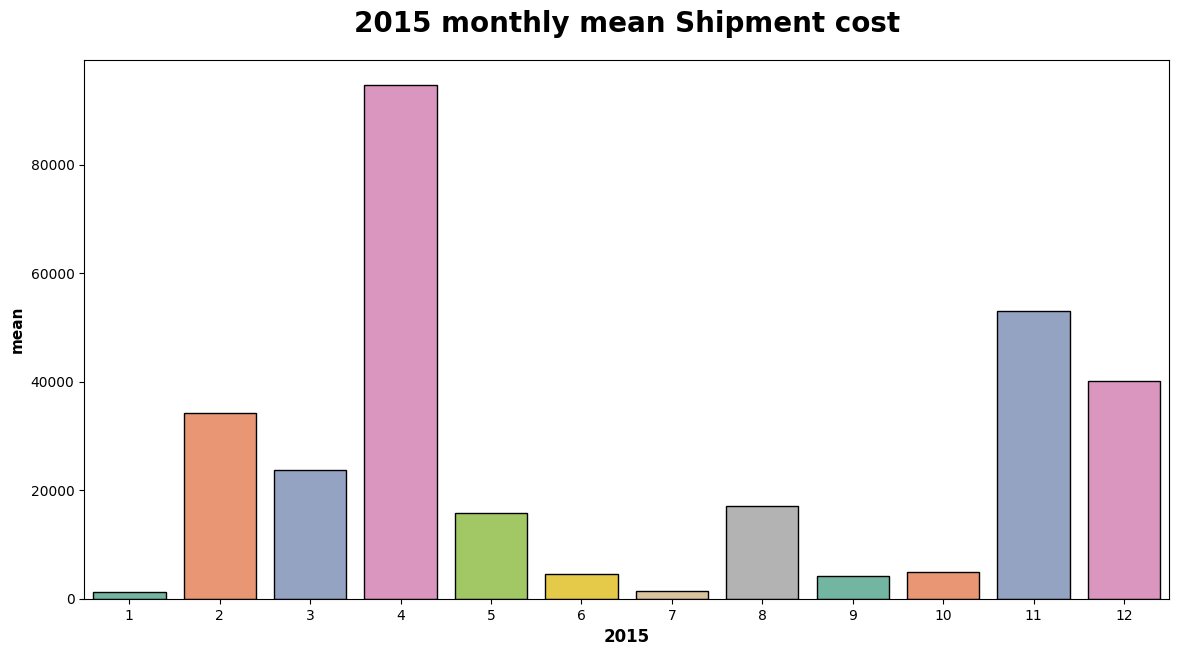

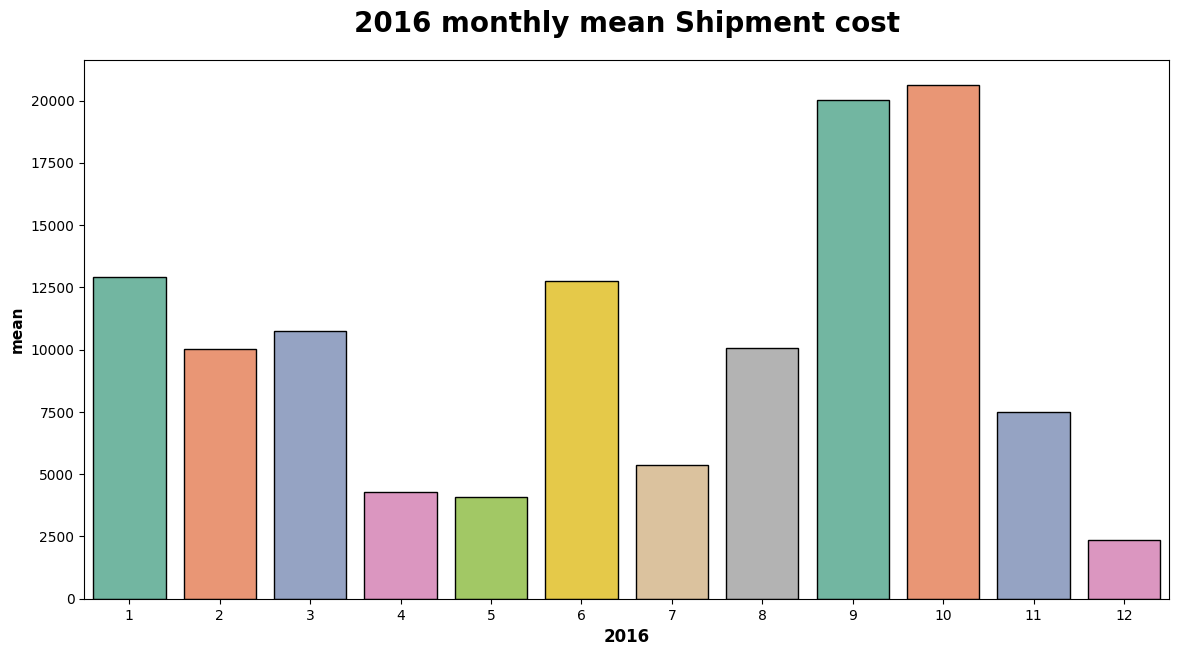

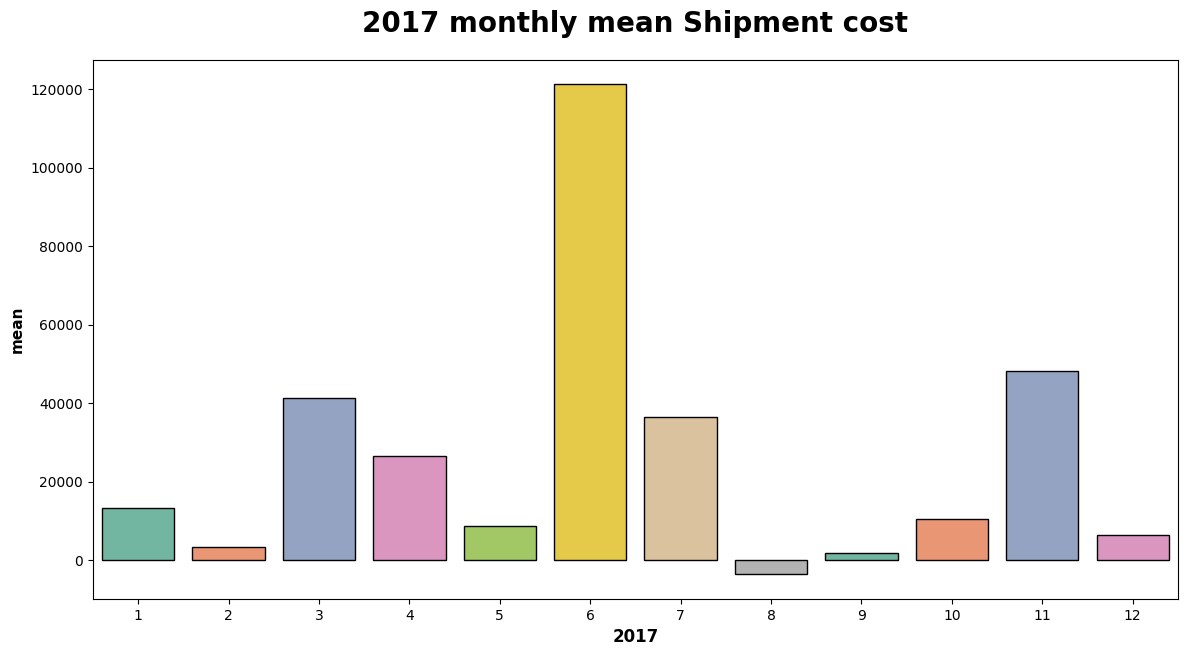

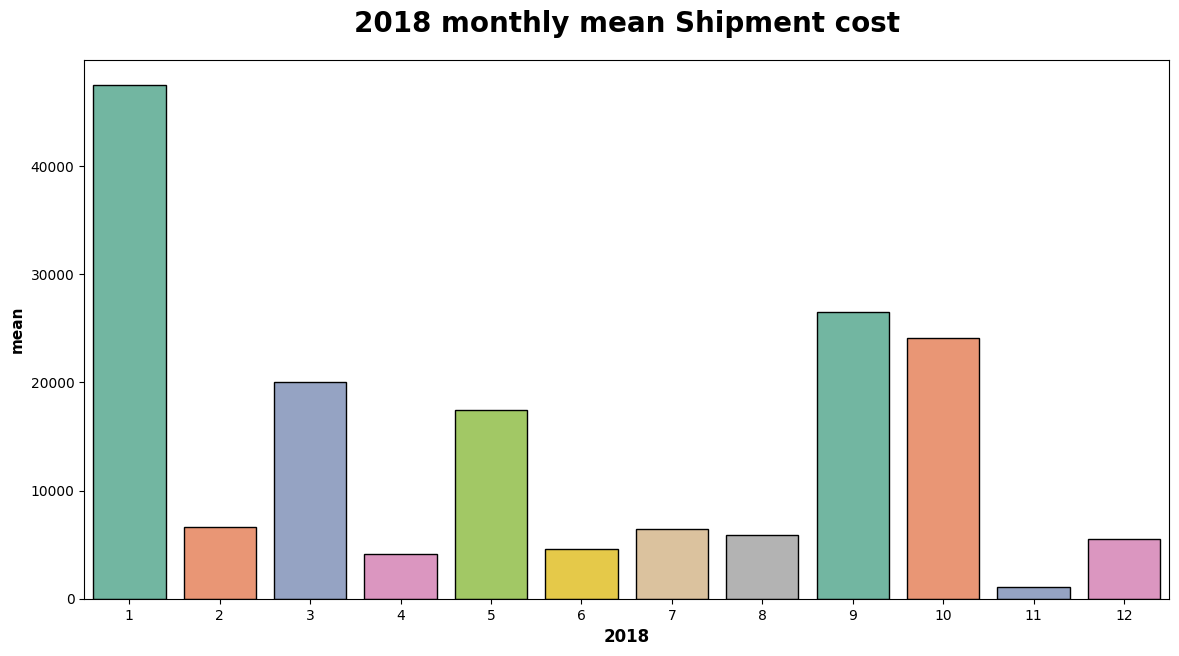

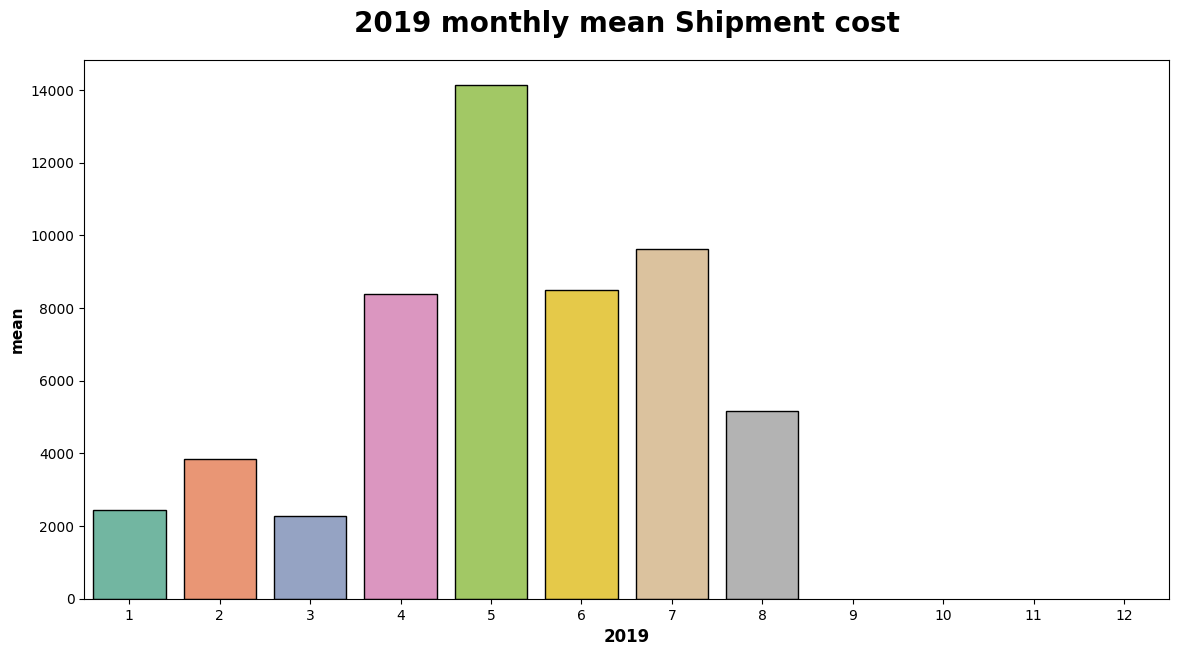

In [26]:
for i in df_wide.columns:
    plt.subplots(figsize=(14,7))
    sns.barplot(y=df_wide[i],x=df_wide.index,ec = "black", palette="Set2")
    plt.title(str(i) + " monthly mean Shipment cost", weight="bold",fontsize=20, pad=20)
    plt.ylabel("mean", weight="bold", fontsize=11)
    plt.xlabel(i, weight="bold", fontsize=12)
    plt.show()

In [27]:
#For 2017 and 2019 cost were high mid year and monthly distribution is different for every year

In [28]:
df

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,Express Shipment,Installation Included,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost,year,month
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,Yes,No,Airways,No,Working Class,No,2015-06-07,2015-06-03,"New Michelle, OH 50777",-283.29,2015,6
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,No,No,Roadways,No,Working Class,No,2017-03-06,2017-03-05,"New Michaelport, WY 12072",-159.96,2017,3
2,fffe3600370035003100,Laura Miller,0.07,8.0,5.0,237.0,Clay,4.96,21.18,No,No,No,Roadways,Yes,Working Class,Yes,2015-03-09,2015-03-08,"Bowmanshire, WA 19241",-154.29,2015,3
3,fffe350031003300,Robert Chaires,0.12,9.0,NaN,NaN,Aluminium,5.81,16.31,No,No,No,NaN,No,Wealthy,Yes,2015-05-24,2015-05-20,"East Robyn, KY 86375",-161.16,2015,5
4,fffe3900320038003400,Rosalyn Krol,0.15,17.0,6.0,324.0,Aluminium,3.18,11.94,Yes,Yes,Yes,Airways,No,Working Class,No,2016-12-18,2016-12-14,"Aprilside, PA 52793",-159.23,2016,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6495,fffe3800370037003300,Jeffrey Freudenthal,0.37,37.0,10.0,16551.0,Brass,28.28,38.46,Yes,Yes,No,Airways,No,Wealthy,Yes,2018-03-28,2018-03-25,"New Robert, VT 85335",872.43,2018,3
6496,fffe310036003400,Larry Edwards,0.67,15.0,NaN,18981.0,NaN,67.18,27.72,No,No,No,Roadways,No,Working Class,No,2015-08-29,2015-08-27,"New Joshua, VA 35766",1347.02,2015,8
6497,fffe3600300031003300,Denise Worth,0.68,19.0,8.0,587.0,Clay,6.92,10.38,Yes,No,No,NaN,Yes,Wealthy,No,2019-04-10,2019-04-09,"Lake Kelly, MA 80823",354.55,2019,4
6498,fffe3600350035003900,Daniel Drew,0.02,33.0,9.0,1269377.0,Stone,2929.13,69.76,No,Yes,No,Roadways,No,Working Class,Yes,2019-03-10,2019-03-12,"Hintonberg, UT 35006",5037.50,2019,3


## **Feature Engineering and Model Training**
**We have completed our analysis part now we need to focus on train set again and make it ready before training**

In [29]:
df = pd.read_csv('/kaggle/input/datasets/oossiiris/hackerearth-machine-learning-exhibit-art/dataset/train.csv')
df.head()

,Customer Id,Artist Name,Artist Reputation,Height,Width,Weight,Material,Price Of Sculpture,Base Shipping Price,International,Express Shipment,Installation Included,Transport,Fragile,Customer Information,Remote Location,Scheduled Date,Delivery Date,Customer Location,Cost
0,fffe3900350033003300,Billy Jenkins,0.26,17.0,6.0,4128.0,Brass,13.91,16.27,Yes,Yes,No,Airways,No,Working Class,No,06/07/15,06/03/15,"New Michelle, OH 50777",-283.29
1,fffe3800330031003900,Jean Bryant,0.28,3.0,3.0,61.0,Brass,6.83,15.00,No,No,No,Roadways,No,Working Class,No,03/06/17,03/05/17,"New Michaelport, WY 12072",-159.96
2,fffe3600370035003100,Laura Miller,0.07,8.0,5.0,237.0,Clay,4.96,21.18,No,No,No,Roadways,Yes,Working Class,Yes,03/09/15,03/08/15,"Bowmanshire, WA 19241",-154.29
3,fffe350031003300,Robert Chaires,0.12,9.0,NaN,NaN,Aluminium,5.81,16.31,No,No,No,NaN,No,Wealthy,Yes,05/24/15,05/20/15,"East Robyn, KY 86375",-161.16
4,fffe3900320038003400,Rosalyn Krol,0.15,17.0,6.0,324.0,Aluminium,3.18,11.94,Yes,Yes,Yes,Airways,No,Working Class,No,12/18/16,12/14/16,"Aprilside, PA 52793",-159.23


In [30]:
features_with_na=[features for features in df.columns if df[features].isnull().sum()>=1]
for feature in features_with_na:
    print(feature,np.round(df[feature].isnull().mean()*100,5), '% missing values')

Artist Reputation 11.53846 % missing values
Height 5.76923 % missing values
Width 8.98462 % missing values
Weight 9.03077 % missing values
Material 11.75385 % missing values
Transport 21.41538 % missing values
Remote Location 11.86154 % missing values


# Checking the duplicates

In [31]:
df.duplicated().sum()

np.int64(0)

# I need to Seperate the features before training process

In [32]:
target_feature = 'Cost'

numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
numeric_features.remove(target_feature)  # here we extract the cost column cause thats out target
non_numeric_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nand {} Non Numeric features : {}'.format(len(non_numeric_features), non_numeric_features))

We have 6 numerical features : ['Artist Reputation', 'Height', 'Width', 'Weight', 'Price Of Sculpture', 'Base Shipping Price']

and 13 Non Numeric features : ['Customer Id', 'Artist Name', 'Material', 'International', 'Express Shipment', 'Installation Included', 'Transport', 'Fragile', 'Customer Information', 'Remote Location', 'Scheduled Date', 'Delivery Date', 'Customer Location']


**Imputing null values with median to check the multicollinearity** 

> Before performing multicollinearity analysis, missing values were imputed using the median of each numerical feature. While more sophisticated techniques such as Multivariate Imputation (MICE) and KNN Imputation can capture relationships between variables, the median was chosen for this exploratory stage due to the characteristics of the dataset. The dataset contains a considerable number of outliers, which can heavily influence mean-based imputations and potentially distort the underlying distribution of the features. The median is a robust statistic that is much less sensitive to extreme values, making it a reliable choice for preserving the central tendency of skewed distributions.

In [33]:
df1 = df.copy()
for i in numeric_features:
    df1[i].fillna(df1[i].median(), inplace=True)

## **We can apply Variance infaltion factor (VIF) ,while we can also apply Heatmap process to detect the multicollinearity**

| VIF    | Meaning                 |
| ------ | ----------------------- |
| 1      | No multicollinearity    |
| 1 - 5  | Low to moderate         |
| 5 - 10 | High                    |
| > 10   | Very high (problematic) |


In [34]:
import statsmodels.api as sm

for i in range(0, len(numeric_features)):
    x = df1.loc[:, df1.columns == numeric_features[i]]
    y = df1.Cost
    model = sm.OLS(x,y) #x is dependent and here y is independent
    results = model.fit()
    rsq = results.rsquared # r square value 
    vif = round(1 / (1 - rsq), 2) # this is the VIF formula cause that is VIF 
    print(
        "Variance Inflation Factor of {} column is {} \n".format(
            numeric_features[i], vif)
        )


Variance Inflation Factor of Artist Reputation column is 1.01 

Variance Inflation Factor of Height column is 1.01 

Variance Inflation Factor of Width column is 1.02 

Variance Inflation Factor of Weight column is 1.2 

Variance Inflation Factor of Price Of Sculpture column is 1.3 

Variance Inflation Factor of Base Shipping Price column is 1.01 



> **As all the columns has value near 1 so there is no multicollinearity problem**

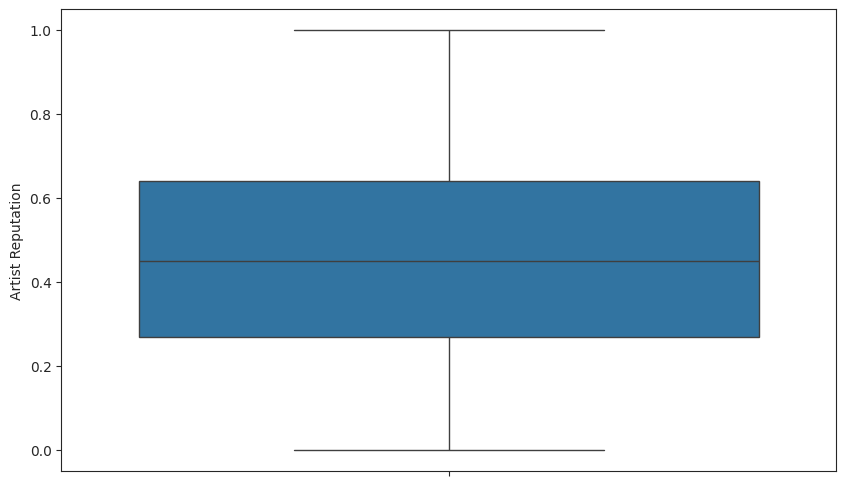

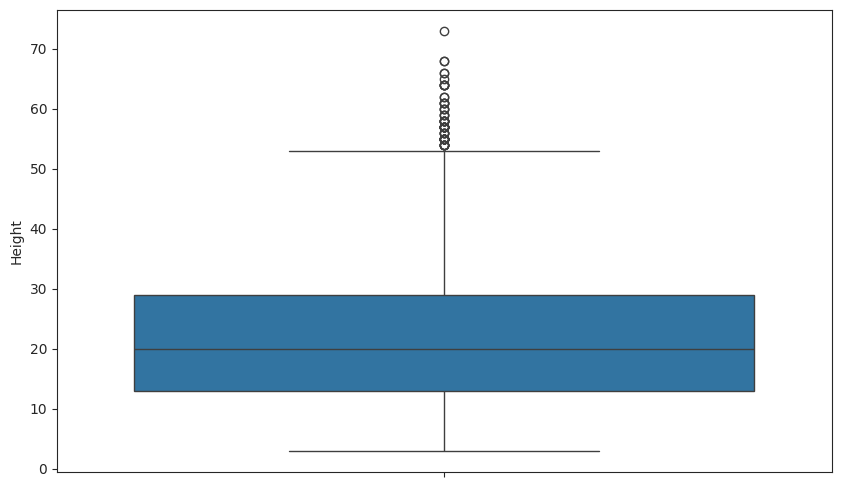

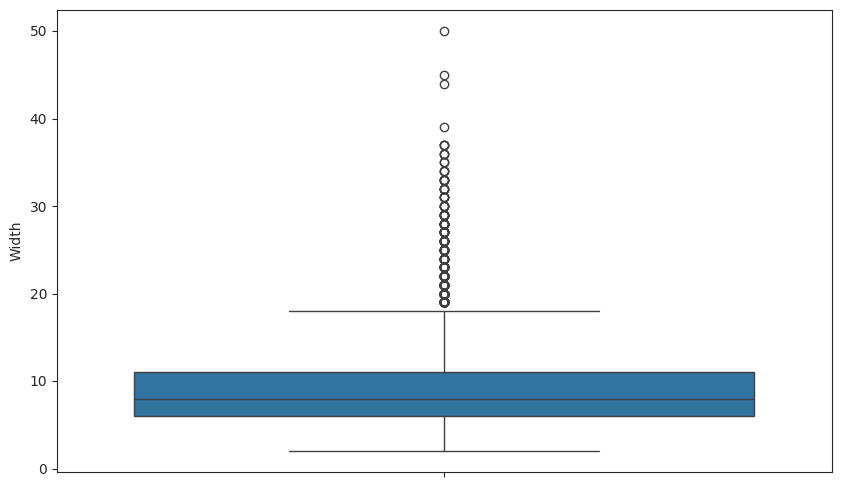

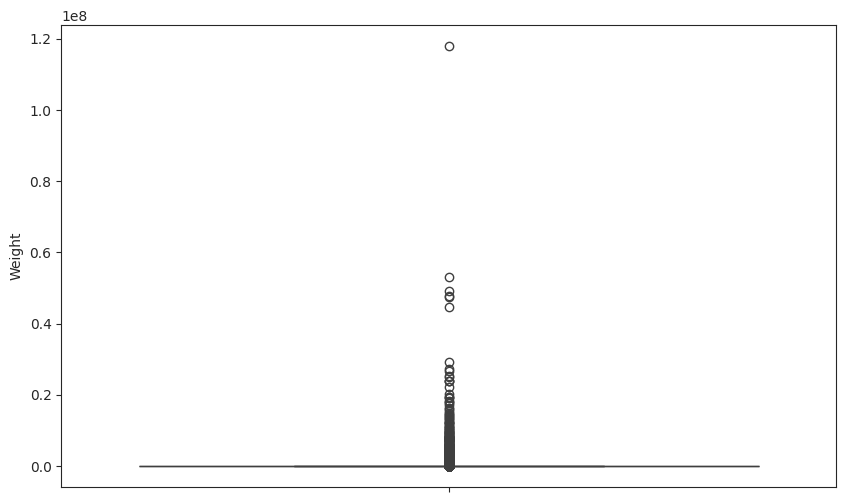

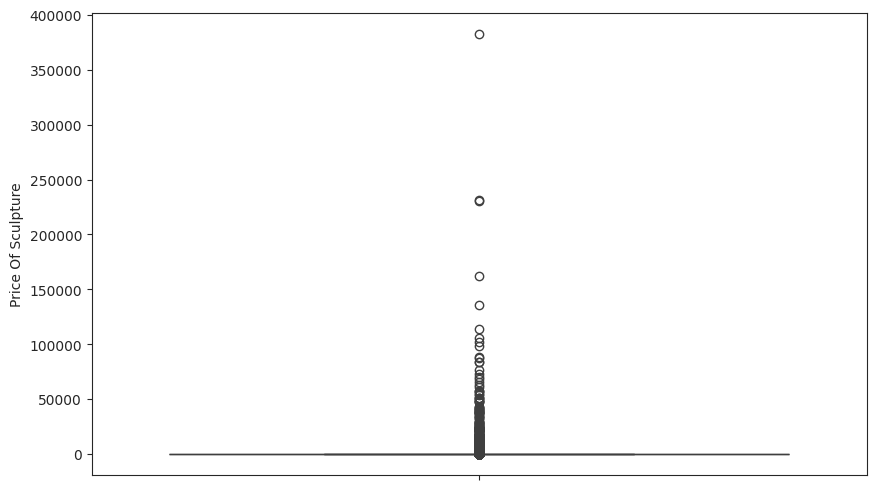

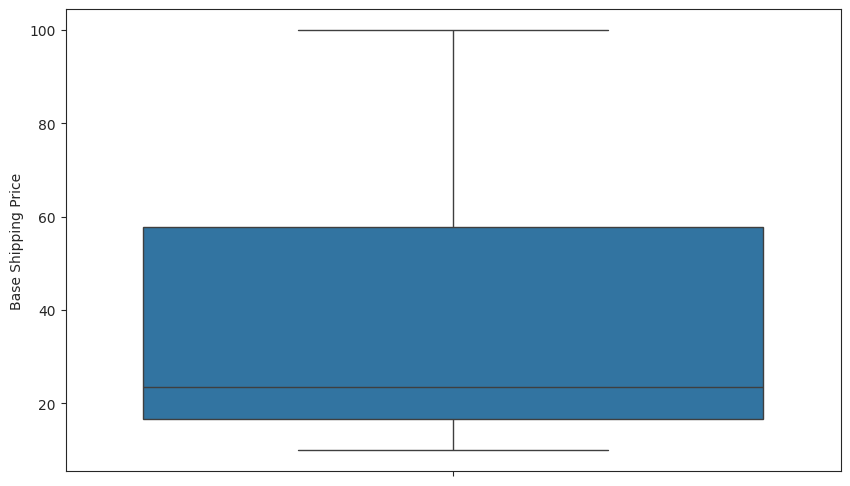

In [35]:
for i in numeric_features:
        plt.figure(figsize=(10,6))
        sns.set_style('ticks')
        ax = sns.boxplot(df1[i])

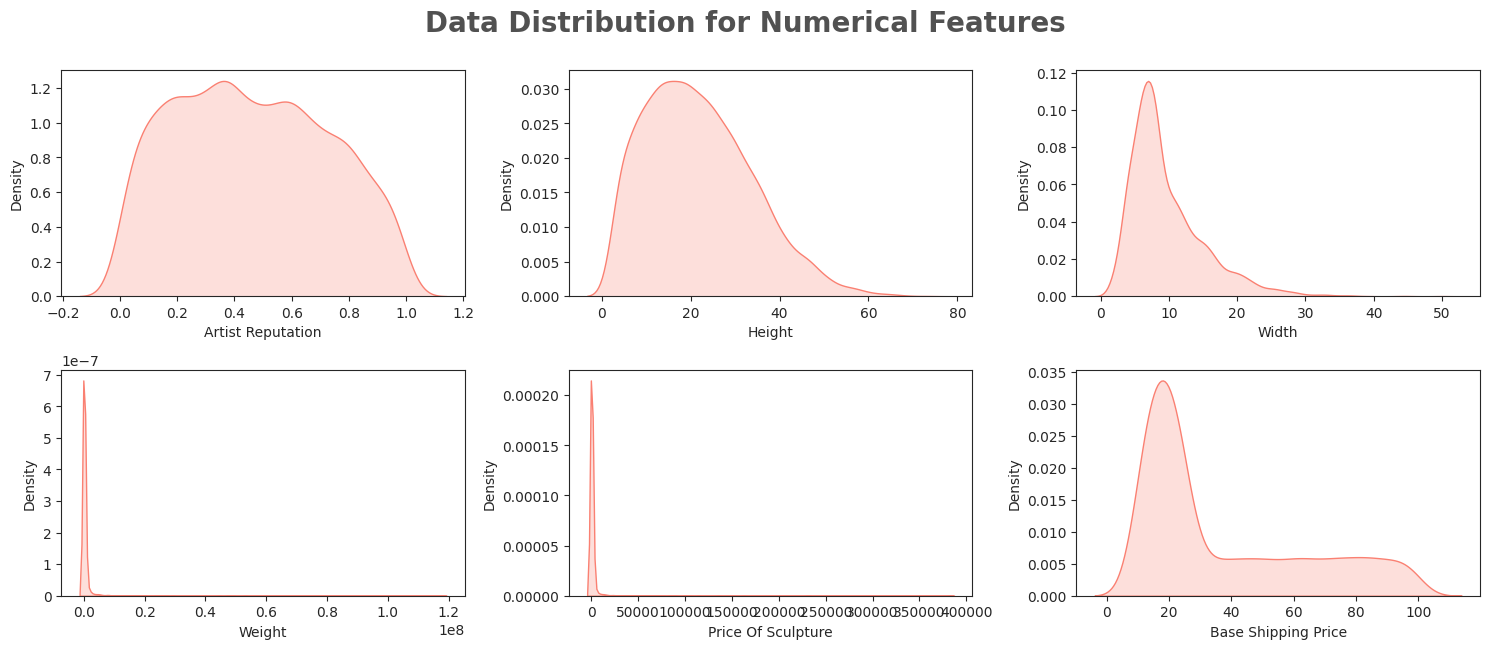

In [36]:
plt.figure(figsize=(15, 15))
plt.suptitle('Data Distribution for Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df[numeric_features[i]],shade=True, color='salmon')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

> | Skewness Value         | Interpretation          |
| ---------------------- | ----------------------- |
| -0.5 to 0.5            | Approximately symmetric |
| 0.5 to 1 or -0.5 to -1 | Moderately skewed       |
| > 1 or < -1            | Highly skewed           |


In [37]:
df[numeric_features].skew()

Artist Reputation       0.141363
Height                  0.594041
Width                   1.546702
Weight                 21.556174
Price Of Sculpture     22.206823
Base Shipping Price     0.918102
dtype: float64

# From the exploratory data analysis (EDA), we observed that Price of Sculpture and Weight exhibit strong positive skewness. This behavior is likely driven by the presence of extreme values and outliers, resulting in long right tails in their distributions.
To reduce the impact of skewness and improve the distributional properties of these features, transformations such as the Log Transformation or Power Transformation (e.g., Yeo-Johnson or Box-Cox) can be applied. These techniques help stabilize variance and make the features more suitable for machine learning models.
Width and Base Shipping Price also show positive skewness; however, their skewness coefficients indicate that the deviation from normality is considerably less severe. Therefore, transformation of these features may provide only marginal benefits compared to the highly skewed variables.

In [38]:
outlier_feature = ['Price Of Sculpture', 'Weight']
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(standardize=False)
outlier_data = df1[outlier_feature]
df1[outlier_feature] = pt.fit_transform(df1[outlier_feature])
df_outlier = pd.DataFrame(outlier_data, columns=outlier_feature)

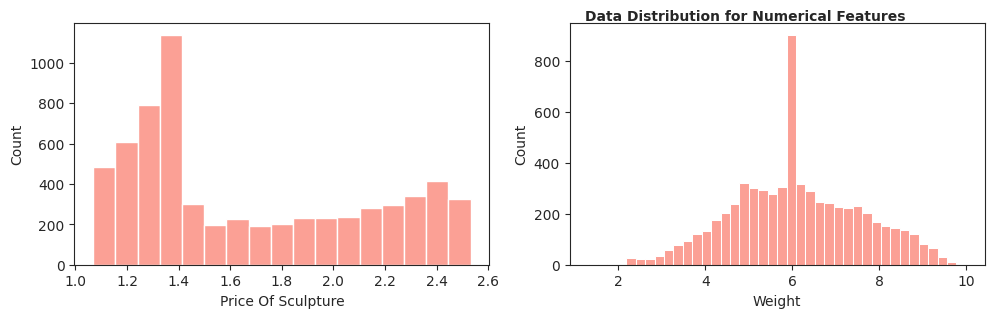

In [39]:
plt.figure(figsize=(15, 15))
plt.suptitle('Data Distribution for Numerical Features', fontsize=10, fontweight='bold',  y=0.98)

for i in range(0, len(outlier_feature)):
    plt.subplot(5, 3, i+1)
    sns.histplot(x=df1[outlier_feature[i]], color='salmon')
    plt.xlabel(outlier_feature[i])
    plt.tight_layout()


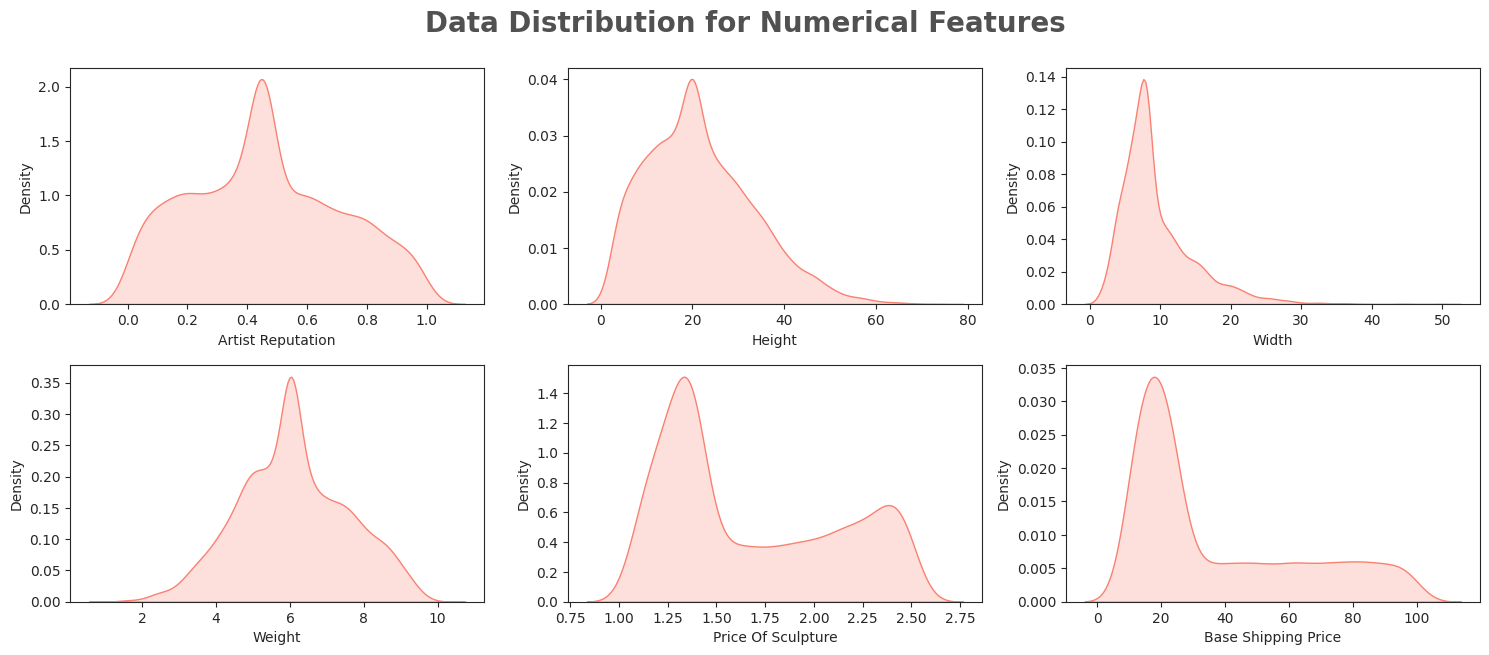

In [40]:
plt.figure(figsize=(15, 15))
plt.suptitle('Data Distribution for Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df1[numeric_features[i]],shade=True, color='salmon')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()


*Power Transformation does NOT remove or change outlier values directly.It reduces the effect of outliers by changing the scale/distribution, not by deleting or capping them.*


## **Now for Cost or Target value**

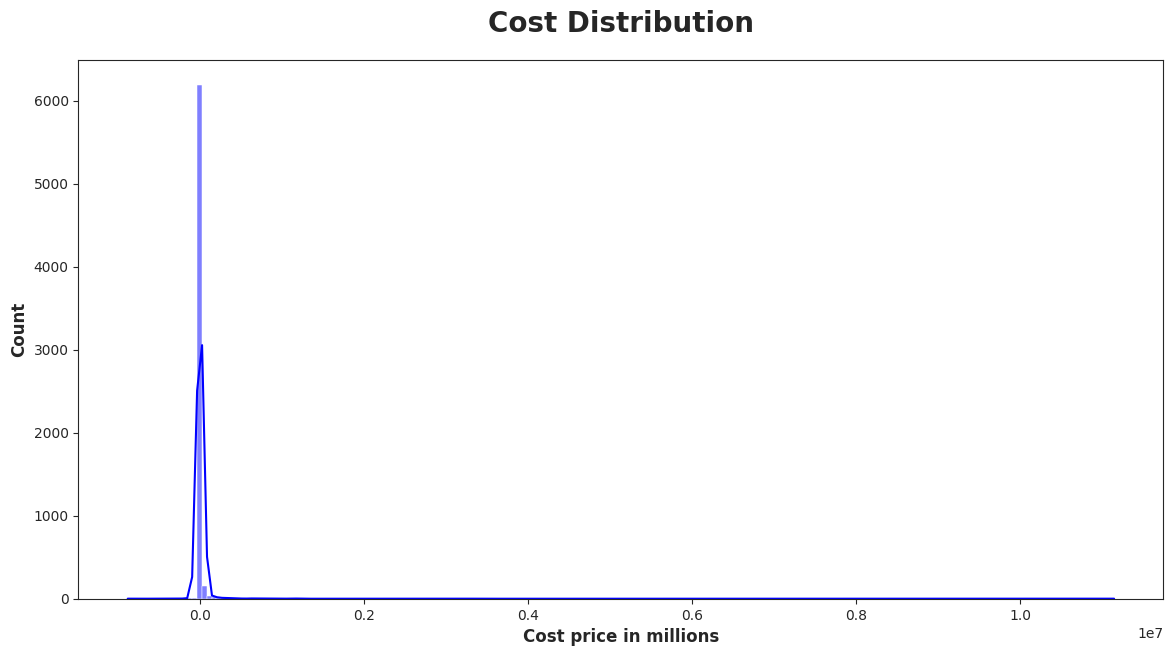

In [41]:
plt.subplots(figsize=(14,7))
sns.histplot(df['Cost'], bins=200, kde=True, color = 'b')
plt.title("Cost Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Cost price in millions", weight="bold", fontsize=12)
plt.show()

**We are using here log transformation**

(array([1973., 1985.,  954.,  461.,  223.,  127.,   64.,   32.,   16.,
           6.]),
 array([ 4.46671239,  5.64267721,  6.81864203,  7.99460685,  9.17057167,
        10.34653649, 11.5225013 , 12.69846612, 13.87443094, 15.05039576,
        16.22636058]),
 <BarContainer object of 10 artists>)

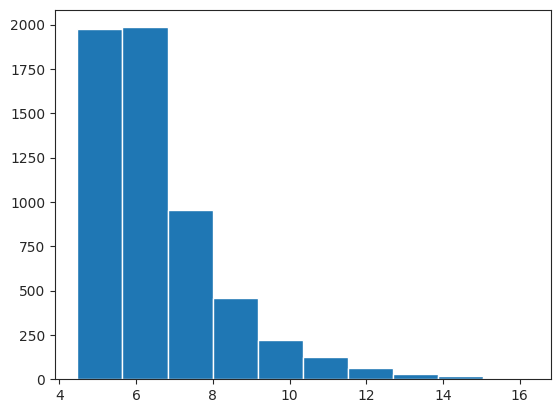

In [42]:
df1['Cost'] = np.log1p(df1['Cost'])
plt.hist(df1['Cost'])

Data looks good after the log transformation but There is no sign of Normally distributed.


In [43]:
df['Scheduled Date'] = pd.to_datetime(df['Scheduled Date'])
df['Delivery Date'] = pd.to_datetime(df['Delivery Date'])
df['Month'] = pd.to_datetime(df['Scheduled Date']).dt.month
df['Year'] = pd.to_datetime(df['Scheduled Date']).dt.year

numeric_features.append('Month')
numeric_features.append('Year')

In [44]:
to_drop_columns = ['Customer Id', 'Artist Name', 'Customer Location', 'Scheduled Date', 'Delivery Date']
df.drop(columns=to_drop_columns, inplace=True)

# Finally Model Building

In [45]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer, LabelEncoder, OrdinalEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

In [46]:
X = df.drop(columns = ['Cost'], axis=1)
y = np.abs(df['Cost'])
y = np.log1p(y)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Encoding and Scaling

In [48]:
numeric_features = [x for x in numeric_features if x not in outlier_feature]
categorical_features = [x for x in non_numeric_features if x not in to_drop_columns]


(numeric_features), (categorical_features), (outlier_feature)

(['Artist Reputation',
  'Height',
  'Width',
  'Base Shipping Price',
  'Month',
  'Year'],
 ['Material',
  'International',
  'Express Shipment',
  'Installation Included',
  'Transport',
  'Fragile',
  'Customer Information',
  'Remote Location'],
 ['Price Of Sculpture', 'Weight'])

I WILL FOLLOW THIS PIPELINE

Numeric columns → impute + scale

Categorical columns → impute + encode

Outlier-heavy columns → impute + transform

We will use column transformer here

In [49]:
numeric_features_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', RobustScaler())
])

categorical_features_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot_encoder', OneHotEncoder()),
]
)

outliers_features_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('transformer', PowerTransformer(standardize=True))
])

preprocessor = ColumnTransformer(
    [
        ("Numeric Pipeline",numeric_features_pipeline, numeric_features),
        ("Categorical Features Pipeline",categorical_features_pipeline, categorical_features),
        ("Outliers Features Pipeline", outliers_features_pipeline, outlier_feature)
]
)

In [50]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [51]:
def evaluate_reg(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

# Model Selection

In [52]:
models = {
    "Linear Regression": LinearRegression()
    # we can add more data
}

model_list = []
r2_score_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)


    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)


    model_train_mae, model_train_rmse, model_train_r2 = evaluate_reg(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_reg(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- RMSE: {:.4f}".format(model_train_rmse))
    print("- MAE: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- RMSE: {:.4f}".format(model_test_rmse))
    print("- MAE: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_score_list.append(model_test_r2)

    print('='*35)
    print('\n')


Linear Regression
Model performance for Training set
- RMSE: 0.7357
- MAE: 0.4971
- R2 Score: 0.8014
----------------------------------
Model performance for Test set
- RMSE: 0.6966
- MAE: 0.4841
- R2 Score: 0.8218


